In [2]:
import time
from pathlib import Path

import h5py
import numpy as np
import pandas
from matplotlib import pyplot as plt

from funbin import funbin
from funbin.penrose import penrose_tiling

In [79]:
plt.rc("figure", figsize=(6, 6))
plt.rc("image", cmap="inferno")
plt.rc("axes", titlesize=10)

# Penrose tilings

## Penrose P1

H-G diagram with HYG star catalog

- [Data source](https://codeberg.org/astronexus/hyg)
- Based loosely on [this notebook](https://github.com/RobertoIA/Hertzsprung-Russell)


In [4]:
hyg = pandas.read_csv("misc/hyg_v42.csv.gz")
hyg = hyg[["absmag", "ci"]]
hyg.dropna(inplace=True)
hyg = hyg[hyg["ci"] < 2.25]

print(hyg.size)
hyg.head()

235100


,absmag,ci
0,4.850,0.656
1,2.390,0.482
2,5.866,0.999
3,-1.619,-0.019
4,2.421,0.370


In [5]:
start = time.time()
penrose_p1 = penrose_tiling(kind="P1", bins=(80, 80))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 25.345 sec


(18.675999999999995, -16.68)

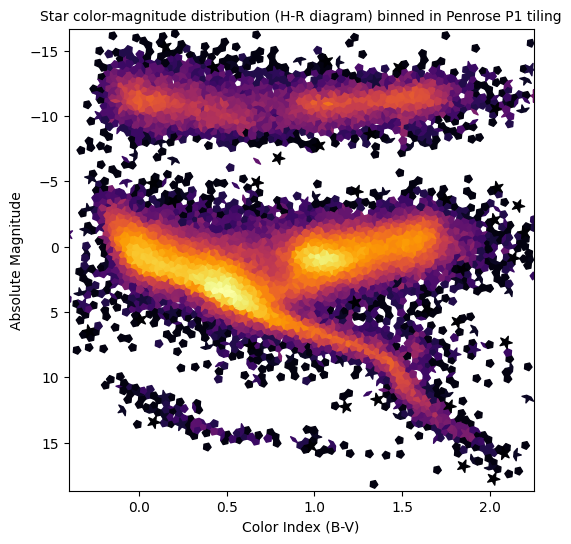

In [80]:
fig, ax = plt.subplots(figsize=(6, 6))

pc = funbin(
    ax,
    x=hyg["ci"].to_numpy(),
    y=hyg["absmag"].to_numpy(),
    tiling=penrose_p1,
    norm="log",
    # edgecolors="lightgray",
    # linewidth=0.3,
)
# fig.colorbar(pc, ax=ax)
ax.set_title("Star color-magnitude distribution (H-R diagram) binned in Penrose P1 tiling")
ax.set_xlabel("Color Index (B-V)")
ax.set_ylabel("Absolute Magnitude")
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymax, ymin)
# fig.savefig(".png", dpi=72)

## Penrose P3

BBH parameter posterior sample from LVK data release. Should have mass ratio at ~golden ratio to make a joke about fat and thick rombi.

- LVK parameter estimation data [release](https://zenodo.org/records/8177023)


In [10]:
available_files = sorted(Path("misc").glob("*.h5"))
print(*available_files, sep="\n")

misc/IGWN-GWTC3p0-v2-GW191103_012549_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191105_143521_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191113_071753_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191126_115259_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191129_134029_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191204_171526_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191215_223052_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191215_223052_PEDataRelease_mixed_nocosmo.h5
misc/IGWN-GWTC3p0-v2-GW200208_130117_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW200302_015811_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW200308_173609_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW191222_033537_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW191230_180458_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW200105_162426_PEDataRelease_mixed_nocosmo.h5
mis

In [71]:
def parse_event_name(filename: str | Path) -> tuple[str, bool]:
    stem = Path(filename).stem
    *_, longname = stem.split("-")
    event_name = longname.split("_")[0]
    is_cosmo = not stem.endswith("nocosmo")
    return event_name, is_cosmo


def read_posterior_sample(filename: str | Path) -> tuple[np.ndarray, list[str]]:
    with h5py.File(filename) as f:
        ps = f["C01:IMRPhenomXPHM"]["posterior_samples"]  # type: ignore
        # source of this monstrosity: numpy structured arrays
        # https://git.ligo.org/lscsoft/pesummary/-/blob/1191d830d9eed4eba6d4f8c3cc7512fb919e5415/pesummary/core/file/formats/pesummary.py#L321
        return np.array([packed.tolist() for packed in ps]).T, list(ps.dtype.names)  # type: ignore

In [61]:
start = time.time()
penrose_p3 = penrose_tiling(kind="P3", bins=(60, 60))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 3.033 sec


In [57]:
file_idx = 2
# candidates:
# 2: weird bi-modal
# 7, 8, 9, 12, 13, 15, 16, 18: close to same-mass
# 10: best, mode close to 1/phi^2
# 17: beautiful and slightly bimodal
filename = available_files[file_idx]
print(f"File: {filename}")
print(f"Size: {filename.stat().st_size / (1024**2):.2f} MiB")
start = time.time()
samples, parameters = read_posterior_sample(filename)
print(f"Data loaded from {filename} in {time.time() - start:.3f} sec")

File: misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5
Size: 221.93 MiB
Data loaded from misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5 in 58.180 sec


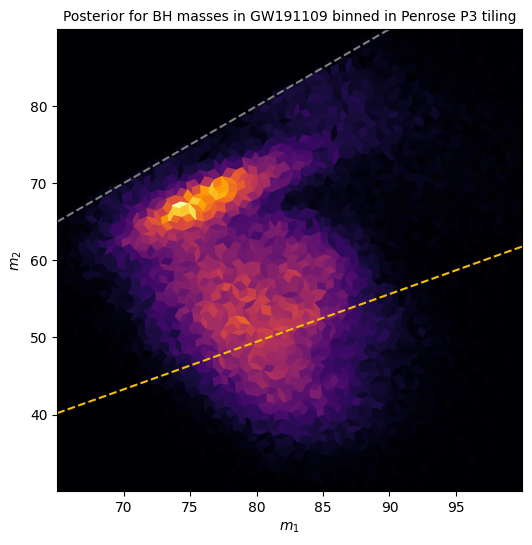

In [84]:
x_param = "mass_1"
y_param = "mass_2"

fig, ax = plt.subplots()

x_idx = parameters.index(x_param)
y_idx = parameters.index(y_param)
x_sample = samples[x_idx, :]
y_sample = samples[y_idx, :]
mask = (x_sample < 100) & (x_sample > 65) & (y_sample < 90) & (y_sample > 30)
# mask = np.ones_like(x_sample, dtype=bool)
funbin(ax, x_sample[mask], y_sample[mask], tiling=penrose_p3)
# ax.hist2d(x_sample[mask], y_sample[mask], bins=60)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
m1_grid = np.linspace(*xlim, 30)
golden_ratio = 1.618033988749
ax.plot(m1_grid, m1_grid, linestyle="--", color="gray")
ax.plot(m1_grid, m1_grid / golden_ratio, linestyle="--", color="xkcd:golden")
# ax.plot(m1_grid, m1_grid / golden_ratio ** (3 / 2), linestyle="-", color="tab:red")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xlabel("$m_1$")
ax.set_ylabel("$m_2$")
event_name, is_cosmo = parse_event_name(filename)
ax.set_title(f"Posterior for BH masses in {event_name} binned in Penrose P3 tiling");

## Penrose P2 (darts and kites)

Ideas:

- BH mass-spin diagram from [COMPAS](https://zenodo.org/records/6346444) (as in [here](https://journals.aps.org/prd/abstract/10.1103/tf4z-71rt))
- SXS collaboration data from [here](https://data.black-holes.org/simulations/index.html)
